# 1. Imports

In [118]:
import importlib
import strategy.prep  # or whatever your module path is
importlib.reload(strategy.prep)
from strategy.prep import prepare_universe

In [119]:
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_ta as ta
import matplotlib.pyplot as plt


# Pull S&P 500 tickers

In [120]:
import pandas as pd
import requests
from io import StringIO


# URL
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

# Add browser headers (fix 403)
headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"
}

# Get page
response = requests.get(url, headers=headers)

# Parse tables
tables = pd.read_html(StringIO(response.text))

# First table is S&P 500 list
sp500 = tables[0]

# Extract tickers
tickers = sp500['Symbol'].tolist()

# Fix Yahoo format (BRK.B -> BRK-B)
tickers = [t.replace('.', '-') for t in tickers]

print("Total tickers:", len(tickers))
print(tickers[:10])

Total tickers: 503
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [121]:
pd.Series(tickers).to_csv("sp500_tickers.csv", index=False, header=False)

# load top 150 liquid stocks

In [122]:
import pandas as pd

tickers = pd.read_csv("sp500_tickers.csv", header=None)[0].tolist()

print(tickers[:20])
print(len(tickers))

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL']
503


In [123]:
tickers = pd.read_csv("sp500_tickers.csv", header=None)[0]

tickers = (
    tickers
    .astype(str)
    .str.strip()
    .str.replace('.', '-', regex=False)
)

tickers = tickers[tickers != ""].tolist()

print("Clean tickers:", len(tickers))

Clean tickers: 503


In [124]:
import yfinance as yf

test = yf.download(tickers[:10], start="2020-01-01", end="2024-01-01")

print(test.head())

[*********************100%***********************]  10 of 10 completed

Price           Close                                                \
Ticker              A       ABBV        ABT         ACN        ADBE   
Date                                                                  
2020-01-02  82.210442  69.266159  77.813873  192.515045  334.429993   
2020-01-03  80.890503  68.608688  76.865242  192.194397  331.809998   
2020-01-06  81.129616  69.150139  77.267952  190.939331  333.709991   
2020-01-07  81.378326  68.755669  76.838387  186.816940  333.390015   
2020-01-08  82.181755  69.242950  77.151619  187.183365  337.869995   

Price                                                               ...  \
Ticker            AES        AFL        AMD        AOS         MMM  ...   
Date                                                                ...   
2020-01-02  15.918977  45.964336  49.099998  42.552326  120.143394  ...   
2020-01-03  15.736179  45.645565  48.599998  42.178200  119.108833  ...   
2020-01-06  15.918977  45.516327  48.389999  42.445427  

In [125]:
import yfinance as yf
test = yf.download(['AAPL','MSFT','NVDA'], start='2020-01-01', end='2024-01-01', progress=False)
print(test.head())

Price           Close                             High                        \
Ticker           AAPL        MSFT      NVDA       AAPL        MSFT      NVDA   
Date                                                                           
2020-01-02  72.400513  152.158417  5.970754  72.460776  152.262622  5.970754   
2020-01-03  71.696648  150.263733  5.875186  72.455966  151.523669  5.918989   
2020-01-06  72.267929  150.652176  5.899824  72.306499  150.718495  5.905050   
2020-01-07  71.928047  149.278564  5.971252  72.533087  151.258458  6.017045   
2020-01-08  73.085098  151.656326  5.982451  73.386416  152.328929  6.023765   

Price             Low                             Open                        \
Ticker           AAPL        MSFT      NVDA       AAPL        MSFT      NVDA   
Date                                                                           
2020-01-02  71.156674  149.989062  5.891364  71.409778  150.415353  5.941885   
2020-01-03  71.472469  149.733237  5.82

In [126]:
import yfinance as yf
import pandas as pd

test_tickers = ["AAPL", "MSFT", "GOOGL"]
raw = yf.download(test_tickers, start="2020-01-01", end="2024-01-01", group_by="ticker", progress=False)

print("Column MultiIndex levels:")
print("  Level 0:", raw.columns.get_level_values(0).unique().tolist())
print("  Level 1:", raw.columns.get_level_values(1).unique().tolist())

price_fields = {'Open', 'High', 'Low', 'Close', 'Volume'}
level0_vals = set(raw.columns.get_level_values(0))
level1_vals = set(raw.columns.get_level_values(1))

print("\nprice_fields & level1_vals:", price_fields & level1_vals)
print("price_fields & level0_vals:", price_fields & level0_vals)

if price_fields & level1_vals:
    ticker_level, price_level = 0, 1
else:
    ticker_level, price_level = 1, 0

print(f"\nticker_level={ticker_level}, price_level={price_level}")

ticker_labels = raw.columns.get_level_values(ticker_level).unique()
print("ticker_labels:", ticker_labels.tolist())

for t in ticker_labels:
    print(f"\n--- {t} ---")
    print(f"  in tickers list: {t in test_tickers}")
    try:
        if ticker_level == 0:
            sub = raw.loc[:, (t, slice(None))]
            sub.columns = sub.columns.droplevel(0)
        else:
            sub = raw.loc[:, (slice(None), t)]
            sub.columns = sub.columns.droplevel(1)
        print(f"  sub.columns: {sub.columns.tolist()}")
        print(f"  all NaN: {sub.isna().all().all()}")
    except Exception as e:
        print(f"  EXCEPTION: {e}")

Column MultiIndex levels:
  Level 0: ['AAPL', 'MSFT', 'GOOGL']
  Level 1: ['Open', 'High', 'Low', 'Close', 'Volume']

price_fields & level1_vals: {'High', 'Close', 'Open', 'Low', 'Volume'}
price_fields & level0_vals: set()

ticker_level=0, price_level=1
ticker_labels: ['AAPL', 'MSFT', 'GOOGL']

--- AAPL ---
  in tickers list: True
  sub.columns: ['Open', 'High', 'Low', 'Close', 'Volume']
  all NaN: False

--- MSFT ---
  in tickers list: True
  sub.columns: ['Open', 'High', 'Low', 'Close', 'Volume']
  all NaN: False

--- GOOGL ---
  in tickers list: True
  sub.columns: ['Open', 'High', 'Low', 'Close', 'Volume']
  all NaN: False


In [127]:
df, tickers_used = prepare_universe(
    sp500_csv="sp500_tickers.csv",
    dynamic=True,
    top_n=150,
    start="2020-01-01",
    end="2024-01-01",
    vol_window=60
)

$GEV: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
$Q: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
$Q: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
$SOLV: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
$SOLV: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
$SNDK: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
$SNDK: possibly delisted; no 

Tickers used:              150
Candidate trades (entries): 489
Avg return:                0.0073
Win rate:                  0.5629


In [128]:
import yfinance as yf
import numpy as np
import pandas as pd

def download_price_data_test(tickers, start, end):
    raw = yf.download(tickers, start=start, end=end, group_by="ticker", progress=False)
    
    out_frames = []
    full_idx = pd.date_range(start=start, end=end, freq='B')
    
    price_fields = {'Open', 'High', 'Low', 'Close', 'Volume'}
    level0_vals = set(raw.columns.get_level_values(0))
    level1_vals = set(raw.columns.get_level_values(1))

    if price_fields & level1_vals:
        ticker_level = 0
    else:
        ticker_level = 1

    ticker_labels = raw.columns.get_level_values(ticker_level).unique()
    tickers_upper = [t.strip().upper() for t in tickers]

    for t in ticker_labels:
        if t not in tickers_upper:
            continue
        try:
            if ticker_level == 0:
                sub = raw.loc[:, (t, slice(None))]
                sub.columns = sub.columns.droplevel(0)
            else:
                sub = raw.loc[:, (slice(None), t)]
                sub.columns = sub.columns.droplevel(1)
        except Exception:
            continue

        if sub.isna().all().all():
            continue

        sub = sub.rename(columns=lambda c: str(c).lower())
        sub.index.name = 'date'
        sub = sub.reset_index()
        sub = sub.rename(columns={'Date': 'date', 'Datetime': 'date', 'index': 'date'})
        sub['ticker'] = t

        for col in ['open', 'high', 'low', 'close', 'volume']:
            if col not in sub.columns:
                sub[col] = np.nan

        sub = sub[['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']]
        s2 = sub.set_index('date').reindex(full_idx).reset_index().rename(columns={'index': 'date'})
        s2['ticker'] = t
        out_frames.append(s2)

    print(f"Frames collected: {len(out_frames)}")
    if out_frames:
        combined = pd.concat(out_frames, ignore_index=True, sort=False)
        print(combined.head())
        return combined

download_price_data_test(["AAPL", "MSFT", "GOOGL"], "2020-01-01", "2024-01-01")

Frames collected: 3
Price       date ticker       open       high        low      close  \
0     2020-01-01  GOOGL        NaN        NaN        NaN        NaN   
1     2020-01-02  GOOGL  66.867843  67.873032  66.772629  67.873032   
2     2020-01-03  GOOGL  66.847529  68.124474  66.813803  67.517982   
3     2020-01-06  GOOGL  67.027518  69.342885  66.996282  69.317596   
4     2020-01-07  GOOGL  69.449002  69.599756  69.007650  69.183693   

Price      volume  
0             NaN  
1      27278000.0  
2      23408000.0  
3      46768000.0  
4      34330000.0  


Price,date,ticker,open,high,low,close,volume
0,2020-01-01,GOOGL,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,GOOGL,66.867843,67.873032,66.772629,67.873032,27278000.0
2,2020-01-03,GOOGL,66.847529,68.124474,66.813803,67.517982,23408000.0
3,2020-01-06,GOOGL,67.027518,69.342885,66.996282,69.317596,46768000.0
4,2020-01-07,GOOGL,69.449002,69.599756,69.007650,69.183693,34330000.0
...,...,...,...,...,...,...,...
3127,2023-12-26,MSFT,368.649516,370.556665,367.174918,368.315277,12673100.0
3128,2023-12-27,MSFT,367.361721,368.708516,366.496618,367.735291,14905400.0
3129,2023-12-28,MSFT,369.013246,370.084784,367.823746,368.924774,14327000.0
3130,2023-12-29,MSFT,369.632605,370.772965,367.155291,369.671936,18730800.0


In [129]:
print("Tickers used:", len(tickers_used))

Tickers used: 150


In [130]:
import yfinance as yf

test_tickers = ["AAPL", "MSFT", "GOOGL"]
raw = yf.download(test_tickers, start="2020-01-01", end="2024-01-01", group_by="ticker", progress=False)

print(type(raw.columns))
print(raw.columns[:10])
print(raw.head(2))

<class 'pandas.MultiIndex'>
MultiIndex([('GOOGL',   'Open'),
            ('GOOGL',   'High'),
            ('GOOGL',    'Low'),
            ('GOOGL',  'Close'),
            ('GOOGL', 'Volume'),
            ( 'AAPL',   'Open'),
            ( 'AAPL',   'High'),
            ( 'AAPL',    'Low'),
            ( 'AAPL',  'Close'),
            ( 'AAPL', 'Volume')],
           names=['Ticker', 'Price'])
Ticker          GOOGL                                                  AAPL  \
Price            Open       High        Low      Close    Volume       Open   
Date                                                                          
2020-01-02  66.867843  67.873032  66.772629  67.873032  27278000  71.409778   
2020-01-03  66.847529  68.124474  66.813803  67.517982  23408000  71.629145   

Ticker                                                        MSFT  \
Price            High        Low      Close     Volume        Open   
Date                                                               

# 2. load data

In [131]:
# Load universe: prefer `tickers_used` (from prepare_universe).
# Fallback: read top 150 tickers from sp500_tickers.csv and clean formatting.
try:
    tickers = tickers_used
    print(f'Registered tickers from prepare_universe: {len(tickers)}')
except NameError:
    tickers = pd.read_csv('sp500_tickers.csv', header=None)[0]
    tickers = (
        tickers.astype(str)
        .str.strip()
        .str.replace('.', '-', regex=False)
        .tolist()
    )[:150]  # take top 150 as a sensible default
    print(f'Falling back to first {len(tickers)} tickers from sp500_tickers.csv')

dfs = []
start = '2020-01-01'
end = '2024-01-01'
# Download per-ticker to avoid MultiIndex complexity and handle missing tickers
for i, ticker in enumerate(tickers, start=1):
    try:
        temp = yf.download(ticker, start=start, end=end, progress=False)
    except Exception as e:
        print(f'Error downloading {ticker}: {e} -- skipping')
        continue
    if temp is None or temp.empty:
        print(f'No data for {ticker}, skipping')
        continue
    # Keep only standard fields and normalize column names
    cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    for c in cols:
        if c not in temp.columns:
            temp[c] = pd.NA
    temp = temp[cols].copy()
    temp.columns = ['open', 'high', 'low', 'close', 'volume']
    temp.index.name = 'date'
    temp = temp.reset_index()
    temp['ticker'] = ticker
    dfs.append(temp)
    if i % 25 == 0:
        print(f'Downloaded {i}/{len(tickers)} tickers...')

if dfs:
    df = pd.concat(dfs, ignore_index=True, sort=False)
    # drop rows that are fully missing for prices
    df = df.dropna(subset=['open', 'high', 'low', 'close'])
else:
    # create empty DataFrame with expected columns if nothing downloaded
    df = pd.DataFrame(columns=['date', 'open', 'high', 'low', 'close', 'volume', 'ticker'])
    print('No price data downloaded for any tickers')

Registered tickers from prepare_universe: 150
Downloaded 25/150 tickers...
Downloaded 25/150 tickers...
Downloaded 50/150 tickers...
Downloaded 50/150 tickers...
Downloaded 75/150 tickers...
Downloaded 75/150 tickers...
Downloaded 100/150 tickers...
Downloaded 100/150 tickers...
Downloaded 125/150 tickers...
Downloaded 125/150 tickers...
Downloaded 150/150 tickers...
Downloaded 150/150 tickers...


# 3. Feature Engineering

In [132]:
df['ema_200'] = df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=200).mean())
df['ema_50'] = df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=50).mean())
df['ema_20'] = df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=20).mean())

# RSI
df['rsi'] = df.groupby('ticker')['close'].transform(lambda x: ta.rsi(x, length=14))

# True range and ATR(14)
high = df['high']
low = df['low']
close = df['close']
df['tr'] = pd.concat([
    high - low,
    (high - close.shift()).abs(),
    (low - close.shift()).abs()
], axis=1).max(axis=1)

df['atr_14'] = df.groupby('ticker')['tr'].transform(lambda x: x.rolling(14, min_periods=1).mean())

# Volume moving average (20) for a simple liquidity filter
df['volume_ma20'] = df.groupby('ticker')['volume'].transform(lambda x: x.rolling(20, min_periods=1).mean())

# 4. Build Strategy Logic

In [133]:
# Trend (price above long-term ema and shorter EMAs aligned)
df['trend'] = (
    (df['close'] > df['ema_200']) &
    (df['ema_20'] > df['ema_50']) &
    (df['ema_50'] > df['ema_200'])
)

# Pullback: price is below the short EMA but above long-term EMA
df['pullback'] = (
    (df['close'] < df['ema_20']) &
    (df['close'] > df['ema_200'])
)

# Oversold and trigger (RSI-based)
df['oversold'] = df['rsi'] < 45

df['trigger'] = (
    (df['rsi'] > df['rsi'].shift(1)) &
    (df['rsi'].shift(1) < 40)
)

# Trend slope: smoother multi-period slope of the ema_200 (20-period diff)
# Use diff(20) to reduce noise; tune window as desired
df['trend_slope'] = df.groupby('ticker')['ema_200'].transform(lambda x: x.diff(20))
df['trend_slope_flag'] = df['trend_slope'] > 0

# Price-strength: close higher than previous close for same ticker
df['price_strength'] = (
    df.groupby('ticker')['close'].transform(lambda x: x > x.shift(1))
).fillna(False)

# Volume filter
df['volume_ok'] = df['volume'] > df['volume_ma20']

# ATR filter (optional): avoid extremely low-volatility entries
# Example threshold: require ATR > median ATR per ticker (tunable)
df['atr_median'] = df.groupby('ticker')['atr_14'].transform('median')
df['atr_ok'] = df['atr_14'] > (0.5 * df['atr_median'])

# Base entry: combine filters; keep as a separate column so we can post-process
# Note: do not yet enforce non-overlap here
df['entry_base'] = (
    df['trend'] &
    df['pullback'] &
    df['oversold'] &
    df['trigger'] &
    df['trend_slope_flag'] &
    df['price_strength'] &
    df['volume_ok'] &
    df['atr_ok']
)

# For compatibility with later code, initialize df['entry'] from entry_base
df['entry'] = df['entry_base'].astype(bool)

# trend strength filter

In [134]:
# Keep trend_strength column for backwards compatibility but use the smoother slope flag
# Replace prior 1-period diff with the 20-period slope-based flag
# (This cell no longer forces entry; it just computes the flag.)
# Note: df['trend_slope_flag'] computed in the strategy logic cell is the primary source
if 'trend_slope_flag' not in df.columns:
    df['trend_slope_flag'] = df.groupby('ticker')['ema_200'].transform(lambda x: x.diff(20) > 0)

# legacy alias
df['trend_strength'] = df['trend_slope_flag']

# 5. Entry Signal

In [135]:
# Final entry signal (still allows a later non-overlap cleaning step)
# This re-assembles the entry using the precomputed flags so it's explicit and easy to audit
df['entry'] = (
    df['trend'] &
    df['pullback'] &
    df['oversold'] &
    df['trigger'] &
    df['trend_slope_flag'] &
    df['price_strength'] &
    df['volume_ok'] &
    df['atr_ok']
)

# Quick sanity check: count candidate entries
print('Candidate entries (before de-overlap):', int(df['entry'].sum()))

Candidate entries (before de-overlap): 628


In [136]:
df['entry'].sum()

np.int64(628)

# Add Stop Loss

In [137]:
# Aligned stop calculations: min low in the next 5 trading days (excluding today)
# Shift by -1 then rolling to aggregate the following 5 days
df['min_low_next_5'] = df.groupby('ticker')['low'].transform(lambda s: s.shift(-1).rolling(5, min_periods=1).min())
# Stop return based on that min low
df['stop_return'] = (df['min_low_next_5'] - df['close']) / df['close']

# ATR-based stop (distance = k * ATR)
k = 2.0
df['stop_price_atr'] = df['close'] - k * df['atr_14']
df['stop_return_atr'] = (df['stop_price_atr'] - df['close']) / df['close']

# Sanity counts
print('Rows with min_low_next_5 NaN (end of series):', int(df['min_low_next_5'].isna().sum()))

Rows with min_low_next_5 NaN (end of series): 0


# forward returns

In [138]:
# Correct future return: explicit future close shifted by 5 days
# This is clearer and less error-prone than pct_change(...).shift(-5)
df['future_close_5'] = df.groupby('ticker')['close'].shift(-5)
df['forward_return_5'] = df['future_close_5'] / df['close'] - 1

# Optional: if you want to see how many NaNs (end of series) exist
print('Future-close NaNs (end of series):', int(df['future_close_5'].isna().sum()))

Future-close NaNs (end of series): 750


# Results?

In [143]:
from strategy.performance import analyze_performance
from strategy.backtest import run_backtest
import pandas as pd
import numpy as np


def _fmt(x):
    """Format a numeric value for display."""
    if x is None:
        return 'n/a'
    try:
        if isinstance(x, float) and (np.isnan(x) or np.isinf(x)):
            return str(x)
        return f'{x:.4f}'
    except Exception:
        return str(x)


# Ensure run_backtest has been executed and produced df_trades + results
needs_run = True
try:
    # if df_trades exists and looks valid, skip running
    if 'df_trades' in globals() and isinstance(df_trades, pd.DataFrame) and not df_trades.empty:
        needs_run = False
except Exception:
    needs_run = True

if needs_run:
    print('Running execution-model backtest (run_backtest) now...')
    df_trades, results = run_backtest(df)
else:
    print('Using existing df_trades from workspace')
    # ensure results variable exists
    if 'results' not in globals() or results is None or (isinstance(results, pd.Series) and results.empty):
        results = df_trades.loc[df_trades.get('entry_nonoverlap', df_trades.get('entry', False)), 'actual_return'].dropna()

# Validation checks per requirements
if 'entry_nonoverlap' not in df_trades.columns:
    raise KeyError("df_trades is missing required column: 'entry_nonoverlap'")
if 'actual_return' not in df_trades.columns:
    raise KeyError("df_trades is missing required column: 'actual_return'")

trades = df_trades.loc[df_trades['entry_nonoverlap'].astype(bool)].copy()

print('\nDebug: actual_return distribution for entry trades:')
print(trades[['actual_return']].describe())
non_null = trades['actual_return'].notna().sum()
print(f'Non-null actual_return values: {non_null}/{len(trades)}')

if non_null == 0:
    raise RuntimeError('No non-null actual_return values found in df_trades — check run_backtest assignment')

# Call analyze_performance exactly once, passing df_trades/trades and explicit return_col
metrics = analyze_performance(trades, return_col='actual_return', interpret=True)

print('\nanalyze_performance returned keys:')
print(list(metrics.keys()))

# Print requested summary stats (mean/median/std) computed directly to avoid key mismatches
mean_return = trades['actual_return'].mean()
median_return = trades['actual_return'].median()
std_return = trades['actual_return'].std()

print('\nPerformance summary:')
print(f'  Number of trades: {len(trades)}')
print(f'  Mean return:      {mean_return:.6f}')
print(f'  Median return:    {median_return:.6f}')
print(f'  Std dev:          {std_return:.6f}')
print(f'  Sharpe ratio:     {_fmt(metrics.get("sharpe"))}')
print(f'  Win rate:         {_fmt(metrics.get("win_rate"))}')
print(f'  Max drawdown:     {_fmt(metrics.get("max_drawdown"))}')

# Make results and df_results available for downstream cells (plotting etc.)
results = trades['actual_return'].dropna()
df_results = results.copy() if len(results) > 0 else pd.Series(dtype=float)

print('\nPerformance evaluation complete.')

Using existing df_trades from workspace

Debug: actual_return distribution for entry trades:
        actual_return
count       485.00000
unique      485.00000
top           0.00132
freq          1.00000
Non-null actual_return values: 485/485
Performance interpretation:
 - Sharpe: 2.6346; very strong
 - Expectancy: 0.0057; positive
 - Profit factor: 1.3829; weak

analyze_performance returned keys:
['win_rate', 'avg_win', 'avg_loss', 'loss_rate', 'expectancy', 'sharpe', 'profit_factor', 'max_drawdown', 'total_return']

Performance summary:
  Number of trades: 485
  Mean return:      0.005718
  Median return:    0.003454
  Std dev:          0.047845
  Sharpe ratio:     2.6346
  Win rate:         0.5381
  Max drawdown:     -0.5329

Performance evaluation complete.
        actual_return
count       485.00000
unique      485.00000
top           0.00132
freq          1.00000
Non-null actual_return values: 485/485
Performance interpretation:
 - Sharpe: 2.6346; very strong
 - Expectancy: 0.0057

# backtest

In [144]:
# Backtest: enforce non-overlapping trades, compute hold lengths and exit prices (no final performance prints)
# Helper to remove overlapping entries within a holding window (per ticker)
def remove_overlaps(entries, hold=5):
    # entries: pandas Series of booleans for a single ticker
    arr = entries.astype(int).values
    out = np.zeros_like(arr)
    i = 0
    n = len(arr)
    while i < n:
        if arr[i]:
            out[i] = 1
            i += hold  # skip the holding window (no new entries)
        else:
            i += 1
    return pd.Series(out.astype(bool), index=entries.index)

# Apply per ticker
hold_window = 5
# Reset index to ensure unique integer index labels and avoid reindexing issues later
# (original df may have duplicate labels after concat). This keeps assignment safe.
df = df.reset_index(drop=True)

# Compute non-overlapping entry mask
df['entry_nonoverlap'] = df.groupby('ticker')['entry'].transform(lambda s: remove_overlaps(s, hold=hold_window))

# Compute hold lengths and exit prices per entry by scanning the next `hold_window` days
# We'll operate per-ticker to avoid crossing boundaries

df['hold_length'] = np.nan
df['exit_price'] = np.nan
for ticker, group in df.groupby('ticker'):
    idx = group.index
    lows = group['low'].values
    sp = group['stop_price_atr'].values if 'stop_price_atr' in group.columns else np.full(len(group), np.nan)
    fc = group['future_close_5'].values if 'future_close_5' in group.columns else np.full(len(group), np.nan)
    en = group['entry_nonoverlap'].values
    n = len(group)
    hl = np.full(n, np.nan)
    ep = np.full(n, np.nan)
    for i in range(n):
        if not en[i]:
            continue
        exit_offset = None
        # scan next days for stop hit
        for offset in range(1, hold_window + 1):
            j = i + offset
            if j >= n:
                break
            if not np.isnan(sp[i]) and lows[j] <= sp[i]:
                exit_offset = offset
                ep[i] = sp[i]
                break
        if exit_offset is None:
            # if we have a future close at day `hold_window`, exit at that price
            if not np.isnan(fc[i]):
                exit_offset = hold_window
                ep[i] = fc[i]
            else:
                exit_offset = np.nan
        hl[i] = exit_offset
    # assign using a Series to ensure index alignment and avoid length mismatch errors
    df.loc[idx, 'hold_length'] = pd.Series(hl, index=idx)
    df.loc[idx, 'exit_price'] = pd.Series(ep, index=idx)

print('Backtest scan complete — performance evaluation deferred to the performance block.')

Backtest scan complete — performance evaluation deferred to the performance block.


In [142]:
# --- Backtest vs Forward-return validation ---
# Use the reusable backtest implementation and compare 'forward_return_5' (theoretical)
# to 'actual_return' produced by the execution model. This is a post-hoc validation
# and does not introduce lookahead bias because it only evaluates realized outcomes.
from strategy.backtest import run_backtest

if __name__ == "__main__":

    # Run the backtest (this prints summary and debug information)
    df_trades, results = run_backtest(df)

    if not isinstance(df_trades, pd.DataFrame) or df_trades.empty:
        raise RuntimeError("run_backtest() returned an empty or invalid df_trades.")

    # Filter only entry rows — prefer entry_nonoverlap, fall back to entry
    if 'entry_nonoverlap' in df_trades.columns:
        entry_mask = df_trades['entry_nonoverlap'].astype(bool)
    elif 'entry' in df_trades.columns:
        entry_mask = df_trades['entry'].astype(bool)
    else:
        raise KeyError("df_trades has neither 'entry_nonoverlap' nor 'entry' column.")

    # Validate required columns exist
    missing = [c for c in ['forward_return_5', 'actual_return'] if c not in df_trades.columns]
    if missing:
        raise KeyError(f"df_trades is missing required columns: {missing}")

    comp = df_trades.loc[entry_mask, ['forward_return_5', 'actual_return']].copy()

    # Drop rows missing either value (we only compare pairs)
    comp = comp.dropna(subset=['forward_return_5', 'actual_return'])
    count = len(comp)

    # Compute stats
    if count > 1:
        corr = comp['forward_return_5'].corr(comp['actual_return'])
        mean_forward = comp['forward_return_5'].mean()
        mean_actual = comp['actual_return'].mean()
    else:
        corr = float('nan')
        mean_forward = comp['forward_return_5'].mean() if count == 1 else float('nan')
        mean_actual = comp['actual_return'].mean() if count == 1 else float('nan')

    # Interpretation
    if pd.isna(corr):
        interpretation = 'Correlation not available (insufficient data)'
    elif corr > 0.7:
        interpretation = 'Signal is holding up well under execution'
    elif corr >= 0.4:
        interpretation = 'Signal partially degrades under execution'
    else:
        interpretation = 'Signal breaks under execution'

    # Output
    print('Forward vs Execution comparison:')
    print(f'  Count:                                           {count}')
    print(f'  Correlation (forward_return_5 vs actual_return): {corr:.4f}' if pd.notna(corr) else '  Correlation: n/a (insufficient paired data)')
    print(f'  Mean forward_return_5:                           {mean_forward:.6f}')
    print(f'  Mean actual_return:                              {mean_actual:.6f}')
    print(f'\nFirst 10 comparison rows:')
    print(comp.head(10).to_string())
    print(f'\nInterpretation:')
    print(f'  {interpretation}')

Backtest summary:
  Number of trades: 485
  Mean return: 0.005718
  Win rate: 53.81%
  Avg hold length: 4.616494845360824
  Max drawdown: 53.29%
  Final capital: $92,614.65 (total return 826.15%)

First 10 trades (entry rows):
trade_id ticker       date entry_price  exit_price hold_length actual_return exit_reason
       1   AAPL 2021-02-26  118.106689   118.26255           5       0.00132        time
       2   AAPL 2021-05-13  121.926987  124.209999           5      0.018724        time
       3   AAPL 2021-10-01   139.38501  139.629242           5      0.001752        time
       4   AAPL 2022-02-24  159.450119  162.869568           5      0.021445        time
       5   AAPL 2022-09-01  155.209442   154.62973           5     -0.003735        time
       6   AAPL 2023-08-08   177.47757  175.394455           5     -0.011737        time
       7   ABBV 2020-08-11   74.631248   77.031174           5      0.032157        time
       8   ABBV 2021-01-28   86.062759   89.630463           

# combine stop loss

In [ ]:
# Combine stop rules and compute actual returns per candidate entry
# Model simple slippage and commission costs
commission = 0.0005  # 0.05% per side (adjust as desired)
slippage = 0.0005   # 0.05% per side

# Start with forward return as the default outcome
df['actual_return'] = df['forward_return_5'].copy()

# If the min low in the next 5 days breaches the ATR-based stop, assume exit at ATR stop price
atr_stop_hit = df['min_low_next_5'] <= df['stop_price_atr']
df.loc[atr_stop_hit, 'actual_return'] = (df.loc[atr_stop_hit, 'stop_price_atr'] / df.loc[atr_stop_hit, 'close']) - 1

# If the min low breaches a fixed 3% hard stop (more conservative), cap the loss at -3%
df['actual_return'] = np.where(df['stop_return'] < -0.03, -0.03, df['actual_return'])

# Subtract round-trip slippage and commissions from realized returns (entry+exit)
df['actual_return'] = df['actual_return'] - (2 * slippage + 2 * commission)

# Some entries near the end will have NaN future returns; keep them as NaN
print('Non-NaN actual returns candidates:', int(df['actual_return'].notna().sum()))

Non-NaN actual returns candidates: 148462


# 7. Visualize

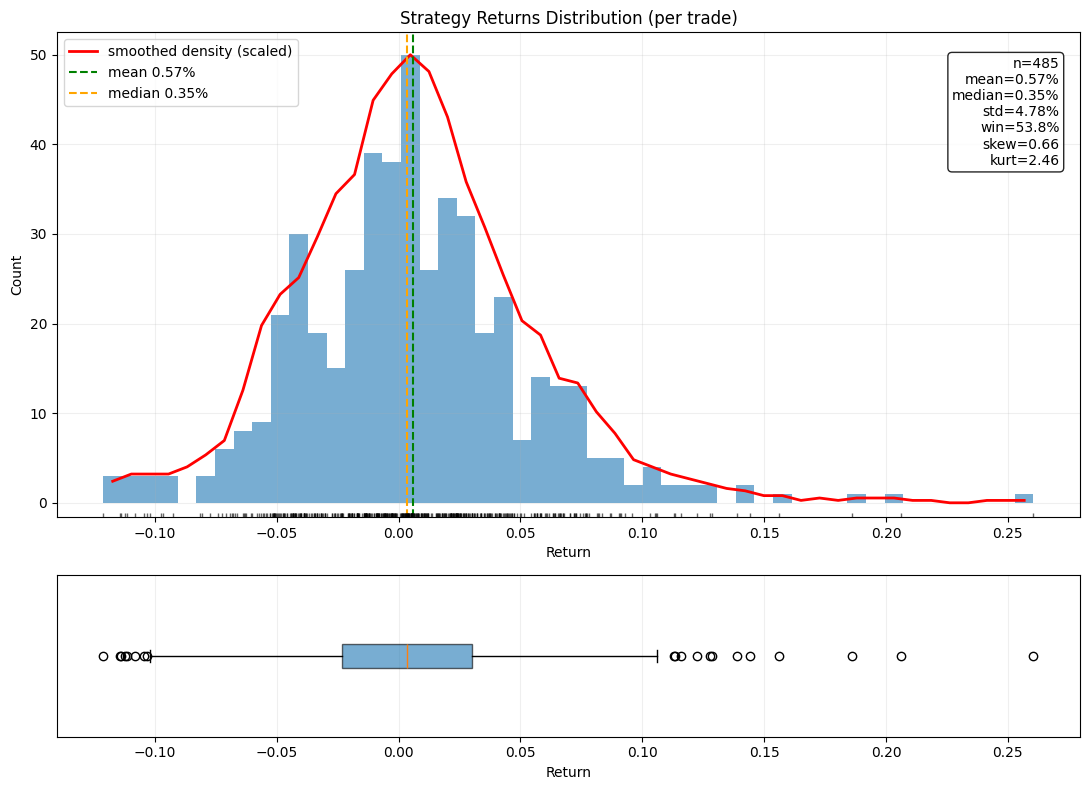

In [145]:
# Detailed strategy returns distribution plot
import numpy as np
import matplotlib.pyplot as plt

# Try to use the `results` Series if it exists; otherwise derive from df
try:
    res = results.dropna()
except Exception:
    res = df[df.get('entry_nonoverlap', df.get('entry', False))]['actual_return'].dropna()

if len(res) == 0:
    print('No trade results available to plot.')
else:
    mean = res.mean()
    median = res.median()
    std = res.std()
    skew = res.skew()
    kurt = res.kurt()
    win_rate = (res > 0).mean()
    count = len(res)

    fig, axs = plt.subplots(2, 1, figsize=(11, 8), gridspec_kw={'height_ratios': [3, 1]})

    bins = 50
    counts, bin_edges, patches = axs[0].hist(res, bins=bins, color='C0', alpha=0.6)

    # Smoothed density (simple moving-average on the histogram's density)
    hist_vals, edges = np.histogram(res, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    if hist_vals.max() > 0:
        smooth = np.convolve(hist_vals, np.ones(5) / 5, mode='same')
        # scale smooth curve to histogram height for visual alignment
        smooth_scaled = smooth * (counts.max() / (smooth.max() + 1e-12))
        axs[0].plot(centers, smooth_scaled, color='red', lw=2, label='smoothed density (scaled)')

    # Vertical lines for mean and median
    axs[0].axvline(mean, color='green', linestyle='--', lw=1.5, label=f'mean {mean:.2%}')
    axs[0].axvline(median, color='orange', linestyle='--', lw=1.5, label=f'median {median:.2%}')

    axs[0].set_title('Strategy Returns Distribution (per trade)')
    axs[0].set_xlabel('Return')
    axs[0].set_ylabel('Count')
    axs[0].grid(alpha=0.2)
    axs[0].legend()

    # Rug plot (small ticks at the bottom)
    ymin, ymax = axs[0].get_ylim()
    rug_y = ymin - 0.03 * (ymax - ymin)
    axs[0].plot(res.values, np.full_like(res.values, rug_y), '|', color='k', alpha=0.6)
    axs[0].set_ylim(rug_y, ymax)

    # Annotated stats box
    stats_txt = (
        f"n={count}\nmean={mean:.2%}\nmedian={median:.2%}\nstd={std:.2%}\nwin={win_rate:.1%}\nskew={skew:.2f}\nkurt={kurt:.2f}"
    )
    props = dict(boxstyle='round', facecolor='white', alpha=0.85)
    axs[0].text(0.98, 0.95, stats_txt, transform=axs[0].transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right', bbox=props)

    # Boxplot of returns for quick summary
    axs[1].boxplot(res.dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='C0', alpha=0.6))
    axs[1].set_xlabel('Return')
    axs[1].set_yticks([])
    axs[1].grid(axis='x', alpha=0.2)

    plt.tight_layout()
    plt.show()

# 8. Interpret Results (Think Like a Quant)

# Simple Backtester

In [146]:
initial_capital = 10000
capital = initial_capital

returns = []

for r in results:
    if pd.notna(r):
        capital *= (1 + r)
        returns.append(capital)

print("Final Capital:", capital)
print("Total Return:", (capital / initial_capital - 1))

Final Capital: 92614.64899228678
Total Return: 8.261464899228677


# Plot Equity Curve

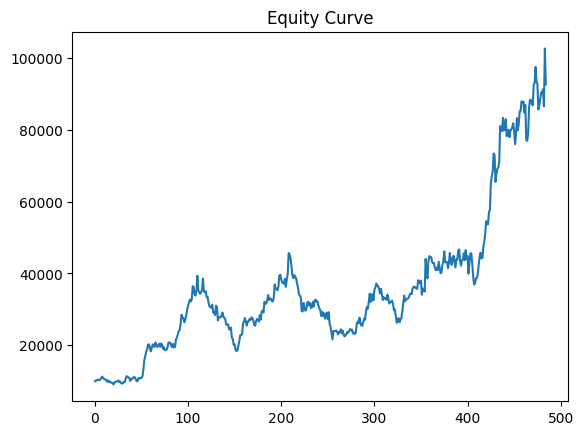

In [147]:
plt.plot(returns)
plt.title("Equity Curve")
plt.show()